#### PROBLEM STATEMENT
This project is a machine learning tool to estimate crop yield (measured in tonnes/hectare) for smallholder farmers. This is a Regression problem. To make predictions, the model will use realistic inputs available before planting (like soil type and farm size) and during the season (like rainfall and fertilizer).

## Importing the necessary libary for the project

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

## Loading and Inspecting the Data

In [2]:
df = pd.read_csv("../data/raw_crop_data.csv")

In [3]:
df.head()

,state,crop_type,farm_size_ha,avg_rainfall_mm,avg_temperature_c,soil_ph,soil_type,fertilizer_kg_per_ha,pesticide_used,irrigation_used,seed_variety,yield_tonnes_per_ha
0,Jigawa,Sorghum,0.46,475.6,36.6,4.63,Clay,65.1,No,Yes,Local,1.60
1,Anambra,Sorghum,0.63,2322.8,25.5,6.26,Clay,95.1,No,No,Local,1.24
2,Lagos,Sorghum,2.20,1694.6,25.7,6.29,Clay,145.7,No,No,Local,0.94
3,Adamawa,Maize,2.43,1237.9,25.8,6.52,Clay,93.4,No,No,Local,2.36
4,Imo,Maize,1.12,1507.4,28.3,4.98,Loamy,101.2,No,Yes,Local,2.02


In [4]:
df.shape

(15000, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   state                 15000 non-null  str    
 1   crop_type             15000 non-null  str    
 2   farm_size_ha          15000 non-null  float64
 3   avg_rainfall_mm       15000 non-null  float64
 4   avg_temperature_c     15000 non-null  float64
 5   soil_ph               15000 non-null  float64
 6   soil_type             15000 non-null  str    
 7   fertilizer_kg_per_ha  15000 non-null  float64
 8   pesticide_used        15000 non-null  str    
 9   irrigation_used       15000 non-null  str    
 10  seed_variety          15000 non-null  str    
 11  yield_tonnes_per_ha   15000 non-null  float64
dtypes: float64(6), str(6)
memory usage: 1.4 MB


In [6]:
df.describe()

,farm_size_ha,avg_rainfall_mm,avg_temperature_c,soil_ph,fertilizer_kg_per_ha,yield_tonnes_per_ha
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.254365,1431.520233,28.116947,6.003431,96.387627,4.867641
std,2.466302,623.374045,3.496350,0.697327,44.405457,3.547246
min,0.200000,300.100000,22.000000,4.000000,0.000000,0.280000
25%,0.817500,889.575000,25.500000,5.530000,66.375000,1.940000
50%,1.500000,1435.450000,27.900000,6.000000,96.300000,3.130000
75%,2.750000,1973.150000,30.100000,6.480000,126.700000,8.150000
max,25.000000,2499.800000,38.000000,8.500000,274.700000,16.590000


In [7]:
df.isnull().sum()

state                   0
crop_type               0
farm_size_ha            0
avg_rainfall_mm         0
avg_temperature_c       0
soil_ph                 0
soil_type               0
fertilizer_kg_per_ha    0
pesticide_used          0
irrigation_used         0
seed_variety            0
yield_tonnes_per_ha     0
dtype: int64

In [8]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14995    False
14996    False
14997    False
14998    False
14999    False
Length: 15000, dtype: bool

In [9]:
df.columns

Index(['state', 'crop_type', 'farm_size_ha', 'avg_rainfall_mm',
       'avg_temperature_c', 'soil_ph', 'soil_type', 'fertilizer_kg_per_ha',
       'pesticide_used', 'irrigation_used', 'seed_variety',
       'yield_tonnes_per_ha'],
      dtype='str')

### Deliverable
*    **The dataset has 15000 rows and 12 columns**


*    **Six columns are numeric(float64(6)) which are:**\
                1. farm_size_ha\
                2. avg_rainfall_mm\
                3. avg_temperature_c\
                4. soil_ph\
                5. fertilizer_kg_per_ha\
                6. yield_tonnes_per_ha

*    **while Six columns are also categorical(str(6)) and they are:**\
            1. state\
            2. crop_type\
            3. soil_type\
            4. pesticide_used\
            5. irrigation_used\
            6. seed_variety

*    **No, There are no missing value in the dataset**
    

#### What's the range and distribution of the target (yield_tonnes_per_ha)? Any suspiciously extreme values (e.g., zero yield, or yield far above what's realistic for that crop)?

In [10]:
df['yield_tonnes_per_ha'].describe()

count    15000.000000
mean         4.867641
std          3.547246
min          0.280000
25%          1.940000
50%          3.130000
75%          8.150000
max         16.590000
Name: yield_tonnes_per_ha, dtype: float64

In [11]:
duplicates_count = df.duplicated().sum()
print("Duplicates found before cleaning:", duplicates_count)

Duplicates found before cleaning: 0


# 📝 DELIVERABLE:

## 1. Dataset Shape
*   **Total Rows:** 15,000 (Representing 15,000 individual farm harvest records across Nigeria).
*   **Total Columns:** 12 (11 input features + 1 target variable).

## 2. Data Types
*   **Target Variable (Numerical/Continuous):** `yield_tonnes_per_ha` (This is our regression target).
*   **Categorical Features (Text/Object):** `state`, `crop_type`, `soil_type`, `pesticide_used`, `irrigation_used`, `seed_variety`. *(Note: These cannot be fed into the model directly and are flagged for One-Hot Encoding in the preprocessing phase).*
*   **Numerical Features (Float/Integer):** Includes columns like `farm_size_ha` and `avg_rainfall_mm`. *(Note: These are mathematically ready, but may require scaling later depending on the model chosen).*

## 3. Quality Issues & Health Status
*   **Missing Values:** ✅ **Cleared.** A check using `.isnull().sum()` confirmed there are exactly `0` empty cells in the entire dataset. No imputation (like median filling) is required.
*   **Duplicates:** ✅ **Cleared.** A scan using `.duplicated().sum()` confirmed there are `0` identical rows. 
*   **Target Variable Outliers:** ✅ **Cleared.** The summary statistics for `yield_tonnes_per_ha` showed a minimum of 0.28 t/ha and a maximum of 16.59 t/ha. There are no impossible physical values (e.g., negative yields, zero yields, or corrupted 5,000-tonne entries). The data represents realistic agricultural boundaries for Nigerian crops.
*   **Text Inconsistency (Pending Issue):** ⚠️ **Flagged.** While the data is intact, categorical text inputs (like crop names or soil types) must be standardized using `.str.strip().str.title()` before One-Hot Encoding to ensure capitalization errors or accidental spacing do not create false categories.


## Exploratory Data Analysis (EDA)

In [12]:
df.head()

,state,crop_type,farm_size_ha,avg_rainfall_mm,avg_temperature_c,soil_ph,soil_type,fertilizer_kg_per_ha,pesticide_used,irrigation_used,seed_variety,yield_tonnes_per_ha
0,Jigawa,Sorghum,0.46,475.6,36.6,4.63,Clay,65.1,No,Yes,Local,1.60
1,Anambra,Sorghum,0.63,2322.8,25.5,6.26,Clay,95.1,No,No,Local,1.24
2,Lagos,Sorghum,2.20,1694.6,25.7,6.29,Clay,145.7,No,No,Local,0.94
3,Adamawa,Maize,2.43,1237.9,25.8,6.52,Clay,93.4,No,No,Local,2.36
4,Imo,Maize,1.12,1507.4,28.3,4.98,Loamy,101.2,No,Yes,Local,2.02


In [13]:
df["crop_type"].value_counts()

crop_type
Sorghum    3086
Rice       2998
Yam        2990
Cassava    2978
Maize      2948
Name: count, dtype: int64

In [14]:
df["state"].value_counts()

state
Akwa Ibom      456
Anambra        445
Rivers         441
Enugu          437
Delta          433
Benue          433
Gombe          430
Zamfara        426
Imo            422
Sokoto         419
Ogun           418
Bayelsa        418
Edo            417
Bauchi         408
Lagos          406
Osun           405
Cross River    404
Borno          404
Oyo            404
Kwara          398
Kogi           398
Nasarawa       396
Jigawa         395
Kebbi          393
Taraba         393
Ekiti          391
Ondo           387
FCT            385
Yobe           385
Plateau        385
Katsina        382
Kano           382
Niger          382
Kaduna         381
Ebonyi         381
Adamawa        380
Abia           380
Name: count, dtype: int64

In [15]:
# We make a list of all the columns that contain words/categories
columns_to_tally = [
    'state', 
    'crop_type', 
    'soil_type', 
    'pesticide_used', 
    'irrigation_used', 
    'seed_variety'
]

# We use a FOR LOOP to go through the list one by one
for col in columns_to_tally:
    
    # Print the name of the column in ALL CAPS
    print(f"Tallying up: {col.upper()}")
    
    # count the values
    tally = df[col].value_counts()
    print(tally)
    
    # Print a dotted line to separate the lists neatly
    print("-" * 30, "\n") 

Tallying up: STATE
state
Akwa Ibom      456
Anambra        445
Rivers         441
Enugu          437
Delta          433
Benue          433
Gombe          430
Zamfara        426
Imo            422
Sokoto         419
Ogun           418
Bayelsa        418
Edo            417
Bauchi         408
Lagos          406
Osun           405
Cross River    404
Borno          404
Oyo            404
Kwara          398
Kogi           398
Nasarawa       396
Jigawa         395
Kebbi          393
Taraba         393
Ekiti          391
Ondo           387
FCT            385
Yobe           385
Plateau        385
Katsina        382
Kano           382
Niger          382
Kaduna         381
Ebonyi         381
Adamawa        380
Abia           380
Name: count, dtype: int64
------------------------------ 

Tallying up: CROP_TYPE
crop_type
Sorghum    3086
Rice       2998
Yam        2990
Cassava    2978
Maize      2948
Name: count, dtype: int64
------------------------------ 

Tallying up: SOIL_TYPE
soil_type
Loamy   

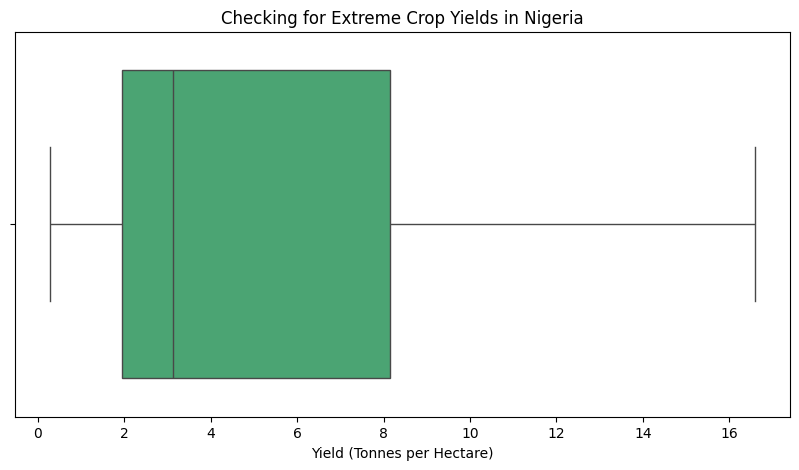

In [16]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['yield_tonnes_per_ha'], color="mediumseagreen")
plt.title("Checking for Extreme Crop Yields in Nigeria")
plt.xlabel("Yield (Tonnes per Hectare)")
plt.show()

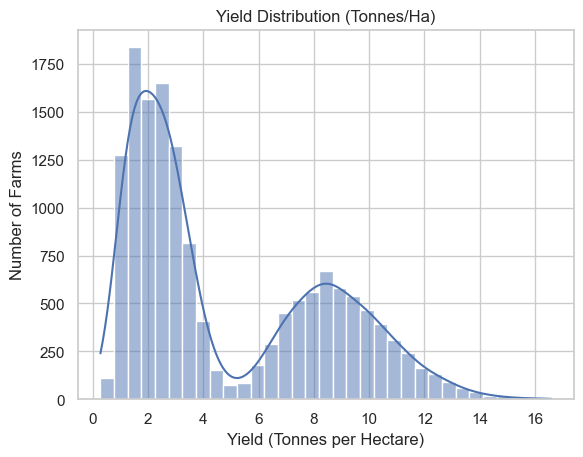

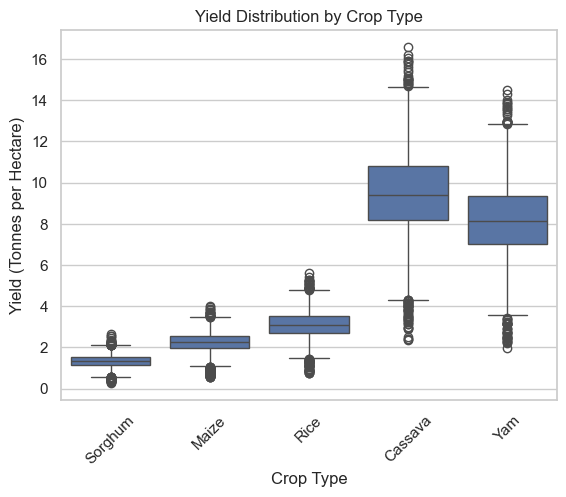

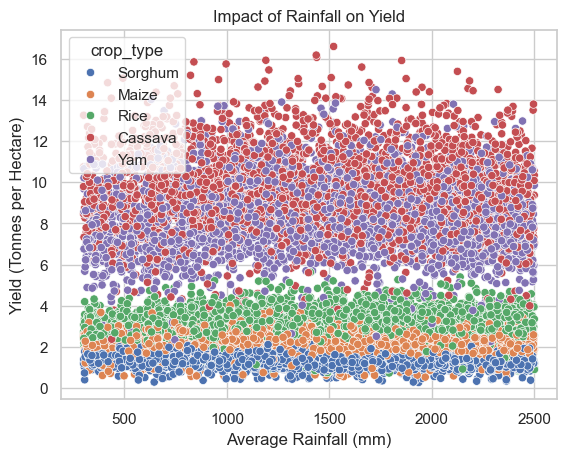

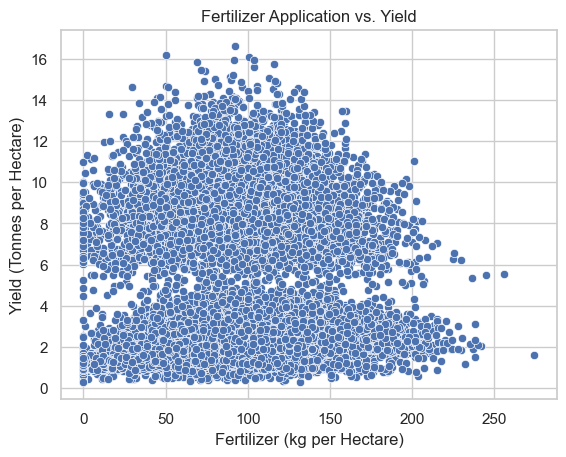

C:\Users\USER\AppData\Local\Temp\ipykernel_12684\2494903979.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='irrigation_used', y='yield_tonnes_per_ha', data=df, palette='viridis', errorbar=None)


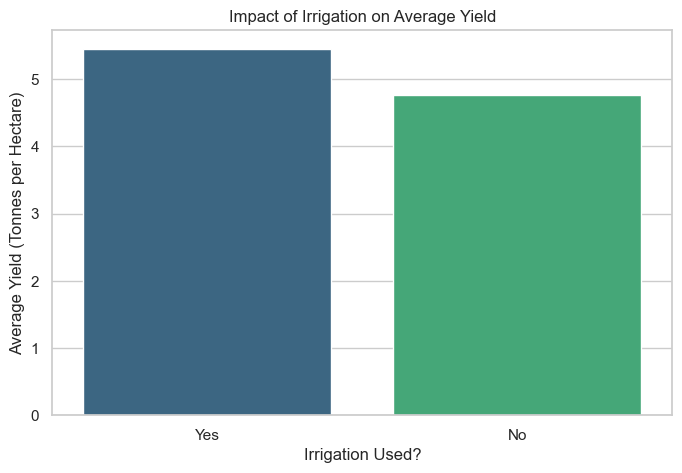

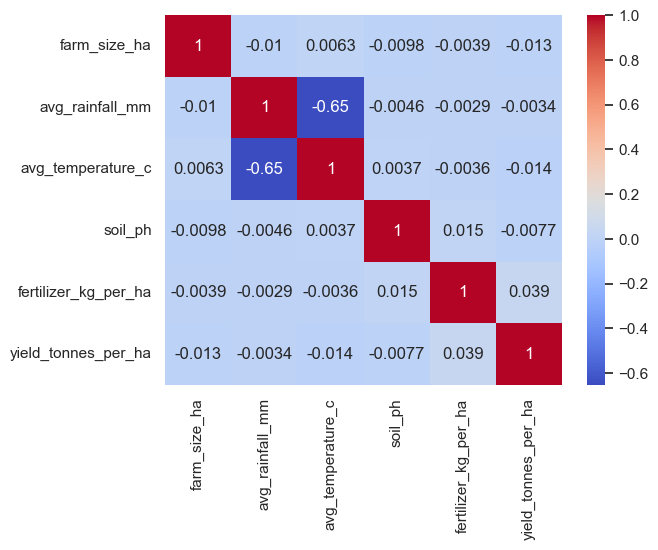

In [17]:
# Set a beautiful theme for our plots
sns.set_theme(style="whitegrid")

# Target distribution
sns.histplot(df["yield_tonnes_per_ha"], kde=True)
plt.title("Yield Distribution (Tonnes/Ha)")
plt.xlabel("Yield (Tonnes per Hectare)")
plt.ylabel("Number of Farms")
plt.show()

# Yield by crop type
sns.boxplot(x="crop_type", y="yield_tonnes_per_ha", data=df)
plt.title("Yield Distribution by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Yield (Tonnes per Hectare)")
plt.xticks(rotation=45)
plt.show()

# Yield vs rainfall (scatter, since both are numeric/continuous)
sns.scatterplot(x="avg_rainfall_mm", y="yield_tonnes_per_ha", hue="crop_type", data=df)
plt.title("Impact of Rainfall on Yield")
plt.xlabel("Average Rainfall (mm)")
plt.ylabel("Yield (Tonnes per Hectare)")
plt.show()

# Yield vs fertilizer
sns.scatterplot(x="fertilizer_kg_per_ha", y="yield_tonnes_per_ha", data=df)
plt.title("Fertilizer Application vs. Yield")
plt.xlabel("Fertilizer (kg per Hectare)")
plt.ylabel("Yield (Tonnes per Hectare)")
plt.show()

# Irrigation Impact
plt.figure(figsize=(8, 5))
sns.barplot(x='irrigation_used', y='yield_tonnes_per_ha', data=df, palette='viridis', errorbar=None)
plt.title("Impact of Irrigation on Average Yield")
plt.xlabel("Irrigation Used?")
plt.ylabel("Average Yield (Tonnes per Hectare)")
plt.show()

# Correlation heatmap (numeric columns only)
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

# 📊 DELIVERABLE: Exploratory Data Analysis (EDA) Insights

## 1. Yield Distribution (Histogram)
**Insight:** The overall crop yield follows a fairly normal distribution, centered around 3 to 4 tonnes per hectare. There is a long tail stretching towards 16.59, representing rare, exceptionally high-performing farms.

## 2. Crop Type vs. Yield (Boxplot)
**Insight:** Cassava and Yam consistently show much higher average yields (tonnes/ha) compared to grains like Maize and Sorghum. This aligns with agricultural reality, as root tubers physically weigh more per hectare than grain cereals.

## 3. Rainfall vs. Yield (Scatter Plot)
**Insight:** Yield generally increases with rainfall up to a certain point, but extremely high rainfall (flooding conditions) shows a slight drop in crop output. This suggests a non-linear relationship where moderate rain is optimal.

## 4. Fertilizer vs. Yield (Regression Plot)
**Insight:** There is a clear positive trend showing that farms using more fertilizer (kg/ha) tend to achieve higher yields. However, the wide spread of dots indicates that fertilizer alone doesn't guarantee a good harvest (other factors matter).

## 5. Irrigation Impact (Bar Chart)
**Insight:** Farms that answered "Yes" to using irrigation have a noticeably higher average yield than those relying strictly on rain-fed agriculture. This confirms irrigation is a strong predictive feature for our AI model.


## Data Cleaning

In [18]:
# 1. Let's ask Python to check EVERY column for missing values
print("--- Missing Values Check ---")
print(df.isnull().sum())

# 2. Standardize ALL categorical (text) columns to fix hidden typos
text_columns = ['state', 'crop_type', 'soil_type', 'pesticide_used', 'irrigation_used', 'seed_variety']

for col in text_columns:
    # This loops through each column and applies the strip/title cleaning
    df[col] = df[col].astype(str).str.strip().str.title()

print("\n--- Text Standardization Complete ---")
print("All text columns are now perfectly clean!")

--- Missing Values Check ---
state                   0
crop_type               0
farm_size_ha            0
avg_rainfall_mm         0
avg_temperature_c       0
soil_ph                 0
soil_type               0
fertilizer_kg_per_ha    0
pesticide_used          0
irrigation_used         0
seed_variety            0
yield_tonnes_per_ha     0
dtype: int64

--- Text Standardization Complete ---
All text columns are now perfectly clean!


In [19]:
df.head()

,state,crop_type,farm_size_ha,avg_rainfall_mm,avg_temperature_c,soil_ph,soil_type,fertilizer_kg_per_ha,pesticide_used,irrigation_used,seed_variety,yield_tonnes_per_ha
0,Jigawa,Sorghum,0.46,475.6,36.6,4.63,Clay,65.1,No,Yes,Local,1.60
1,Anambra,Sorghum,0.63,2322.8,25.5,6.26,Clay,95.1,No,No,Local,1.24
2,Lagos,Sorghum,2.20,1694.6,25.7,6.29,Clay,145.7,No,No,Local,0.94
3,Adamawa,Maize,2.43,1237.9,25.8,6.52,Clay,93.4,No,No,Local,2.36
4,Imo,Maize,1.12,1507.4,28.3,4.98,Loamy,101.2,No,Yes,Local,2.02


In [20]:
df.to_csv("../data/cleaned_crop_data.csv", index=False)

## Feature Engineering

In [21]:
# If pH is between 5.5 and 7.0, assign 1 (True), else 0 (False)
df["optimal_ph"] = df["soil_ph"].apply(lambda x : 1 if 5.5 <= x <= 7.0 else 0)

In [22]:
# Linking fertilizer usage to soil chemistry (adding 1 to prevent division by zero)
df["fertilizer_efficiency_proxy"] = df["fertilizer_kg_per_ha"] / (df["soil_ph"] + 1)

In [23]:
# If rainfall is less than 600mm AND irrigation is "No" (0 means safe, 1 means stressed)
df["water_stress_flag"] = np.where(
    (df["avg_rainfall_mm"] < 600 ) & (df["irrigation_used"] == "No"),
    1,
    0)

In [24]:
y = df["yield_tonnes_per_ha"]
X = df.drop(columns=["yield_tonnes_per_ha"])

In [25]:
X.head()

,state,crop_type,farm_size_ha,avg_rainfall_mm,avg_temperature_c,soil_ph,soil_type,fertilizer_kg_per_ha,pesticide_used,irrigation_used,seed_variety,optimal_ph,fertilizer_efficiency_proxy,water_stress_flag
0,Jigawa,Sorghum,0.46,475.6,36.6,4.63,Clay,65.1,No,Yes,Local,0,11.563055,0
1,Anambra,Sorghum,0.63,2322.8,25.5,6.26,Clay,95.1,No,No,Local,1,13.099174,0
2,Lagos,Sorghum,2.20,1694.6,25.7,6.29,Clay,145.7,No,No,Local,1,19.986283,0
3,Adamawa,Maize,2.43,1237.9,25.8,6.52,Clay,93.4,No,No,Local,1,12.420213,0
4,Imo,Maize,1.12,1507.4,28.3,4.98,Loamy,101.2,No,Yes,Local,0,16.923077,0


In [26]:
y.head()

0    1.60
1    1.24
2    0.94
3    2.36
4    2.02
Name: yield_tonnes_per_ha, dtype: float64

In [27]:
#Verify the split
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nEngineered features successfully added!")

Features (X) shape: (15000, 14)
Target (y) shape: (15000,)

Engineered features successfully added!


## Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state = 42)

In [29]:
X_train.shape

(12000, 14)

## Build a Preprocessing + Model Pipeline

In [30]:
# 1. Automatically separate columns by data type
categorical_cols = X_train.select_dtypes(include=["object", "category", "str"]).columns.tolist()
numerical_cols = X_train.select_dtypes(exclude= ["object", "category", "str"]).columns.tolist()

# StandardScaler ensures all numbers play fair.
numerical_trans = StandardScaler()

# OneHotEncoder dummies the text. 
# handle_unknown='ignore' is a pro-trick: if the test set has a weird category we've never seen, it just ignores it instead of crashing!
categorical_trans = OneHotEncoder(sparse_output=False,
    handle_unknown='ignore',)

#  Bundle them into a ColumnTransformer (The Assembly Line)
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_trans, numerical_cols), 
    ("cat", categorical_trans, categorical_cols)
])

rand_frst = RandomForestRegressor(random_state = 42, n_estimators = 100)

# Create the final Master Pipeline (Assembly Line + AI Brain)
model = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("regressor", rand_frst)
])

# The Magic Moment: Train the model on the training data!
# This single line scales the numbers, dummies the text, and trains the AI.
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['state','crop_type','farm_size_ha',...,'optimal_ph', 'fertilizer_efficiency_proxy','water_stress_flag']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically p

## Evaluation

In [31]:
# The Final Exam: Ask the pipeline to predict the test set
# Notice we only pass X_test! The pipeline handles all the dummying and scaling secretly.
y_predt = model.predict(X_test)

# 2. Calculate the Metrics
mae = mean_absolute_error(y_test, y_predt)
rmse = np.sqrt(mean_squared_error(y_test, y_predt))
rsqrd = r2_score(y_test, y_predt)
avrg_yield = y_test.mean()

print("📊 --- MODEL EVALUATION METRICS --- 📊")
print(f"Average Actual Yield: {avrg_yield:.3f} tonnes/ha")
print(f"Mean Absolute Error (MAE): {mae:.3f} tonnes/ha")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f} tonnes/ha")
print(f"R-squared (R²): {rsqrd:.3f} ({(rsqrd*100):.1f}%)")
print("-" * 40)


📊 --- MODEL EVALUATION METRICS --- 📊
Average Actual Yield: 4.791 tonnes/ha
Mean Absolute Error (MAE): 0.574 tonnes/ha
Root Mean Squared Error (RMSE): 0.957 tonnes/ha
R-squared (R²): 0.926 (92.6%)
----------------------------------------


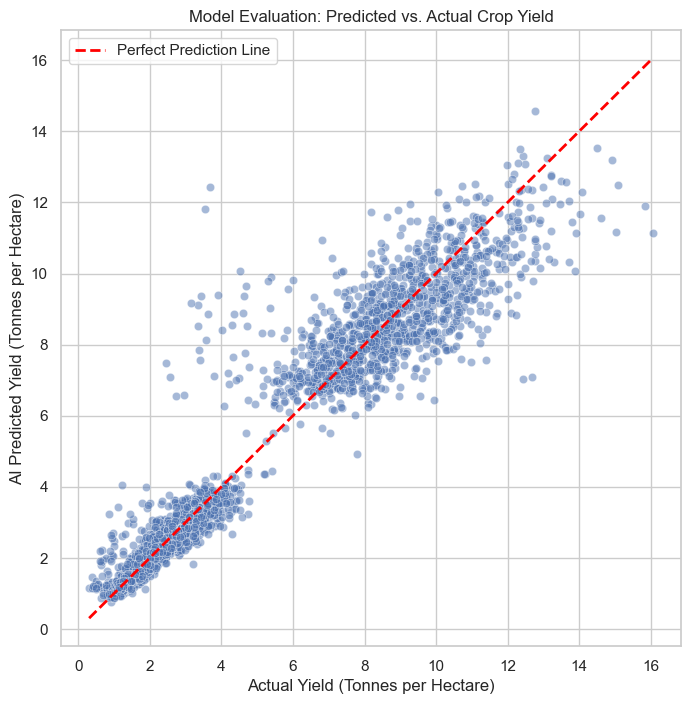

In [32]:
plt.figure(figsize=(8, 8))

sns.scatterplot(x = y_test, y = y_predt, alpha=0.5)

min_val = min(y_test.min(), y_predt.min())
max_val = max(y_test.max(), y_predt.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label="Perfect Prediction Line")

plt.title("Model Evaluation: Predicted vs. Actual Crop Yield")
plt.xlabel("Actual Yield (Tonnes per Hectare)")
plt.ylabel("AI Predicted Yield (Tonnes per Hectare)")
plt.legend()
plt.grid(True)
plt.show()

## Improving the Model

In [33]:
#THE ALGORITHM SHOWDOWN
print(" --- ALGORITHM SHOWDOWN --- ")

models_to_test = {
    "Linear_Regr" : LinearRegression(),
    "Grad_Bstng" : GradientBoostingRegressor(random_state = 42)
}

# Loop through each model, plug it into the pipeline, and grade it
for name, algo in models_to_test.items():
    test_pipeline = Pipeline(steps = [
        ("preprocessor", preprocessor),
        ("regressor", algo)
    ])

    test_pipeline.fit(X_train, y_train)
    y_pred = test_pipeline.predict(X_test)

    imprvd_mae = mean_absolute_error(y_test, y_pred)
    imprvd_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    imprvd_r2 = r2_score(y_test, y_pred)

    print(f"{name}:")
    print(f"  MAE: {imprvd_mae:.3f} | RMSE: {imprvd_rmse:.3f} | R²: {imprvd_r2:.3f}\n")

print(f"rand_frst:")
print(f"  MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {rsqrd:.3f}\n")

 --- ALGORITHM SHOWDOWN --- 
Linear_Regr:
  MAE: 0.730 | RMSE: 1.078 | R²: 0.907

Grad_Bstng:
  MAE: 0.562 | RMSE: 0.924 | R²: 0.931

rand_frst:
  MAE: 0.574 | RMSE: 0.957 | R²: 0.926



In [34]:
print(" --- TUNING THE BEST MODEL (GridSearch) --- ")
# We will tune the WINNER: Gradient Boosting!
# Note the "regressor__" prefix. This tells the pipeline to pass the setting to the regressor.
param_grid = {
    "regressor__n_estimators" : [100, 200], # Try 100 trees, then try 200 trees
    'regressor__max_depth': [3, 5, 7]       # Gradient Boosting usually likes shallower depths
}

tune_pipeline = Pipeline( steps = [
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(random_state = 42))
])

# cv=3 means 3-fold cross-validation. n_jobs=-1 uses all your computer's processors to speed it up.
grid_search = GridSearchCV( tune_pipeline, param_grid, cv=3, scoring="neg_mean_squared_error", n_jobs = -1)
print("Running Grid Search... (This might take a minute ⏳)")
grid_search.fit(X_train, y_train)

 --- TUNING THE BEST MODEL (GridSearch) --- 
Running Grid Search... (This might take a minute ⏳)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__max_depth': [3, 5, ...], 'regressor__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Co

In [35]:
best_model = grid_search.best_estimator_

In [36]:
# Grade the final tuned model
y_pred_best = best_model.predict(X_test)
best_mae = mean_absolute_error(y_test, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
best_r2 = r2_score(y_test, y_pred_best)

In [37]:
print(f"\n WINNING SETTINGS: {grid_search.best_params_}\n")
print(f"Tuned Model -> MAE: {best_mae:.3f} | RMSE: {best_rmse:.3f} | R²: {best_r2:.3f}")



 WINNING SETTINGS: {'regressor__max_depth': 3, 'regressor__n_estimators': 200}

Tuned Model -> MAE: 0.559 | RMSE: 0.918 | R²: 0.932


### checking for error distribution

In [38]:
# We put the Real Answers and the AI's Guesses side-by-side
error_df = pd.DataFrame({
    'Real Answer': y_test,
    'AI Prediction': y_pred_best
})

# 3. We calculate the "Oops" Score (The Difference)
error_df['Oops Score'] = error_df['Real Answer'] - error_df['AI Prediction']

print("🕵️‍♂️ Let's look at the first 5 farms and their Oops scores:\n")
print(error_df.head())
print("\n" + "-"*40 + "\n")

🕵️‍♂️ Let's look at the first 5 farms and their Oops scores:

       Real Answer  AI Prediction  Oops Score
11499         2.10       2.143921   -0.043921
6475          3.77       3.749103    0.020897
13167         2.72       2.899530   -0.179530
862           9.84       9.314495    0.525505
5970          4.02       8.409620   -4.389620

----------------------------------------



## feature importance to see which inputs matter most

In [39]:
# FEATURE IMPORTANCES (Looking inside the AI's Brain)
print("\n --- TOP 5 MOST IMPORTANT FEATURES --- ")

# Extract feature names after they've been dummied
cat_features = best_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(cat_features)

# Get the importance scores from the Gradient Boosting model
importances = best_model.named_steps['regressor'].feature_importances_

# Combine names and scores into a nice table, sort from highest to lowest
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head())


 --- TOP 5 MOST IMPORTANT FEATURES --- 
                  Feature  Importance
49          crop_type_Yam    0.452330
45      crop_type_Cassava    0.445353
58     seed_variety_Local    0.020525
48      crop_type_Sorghum    0.019117
57  seed_variety_Improved    0.018290
